# Analyse des accidents corporels de la circulation en France (2015–2020)

**Problématique :** Quels facteurs (environnementaux, comportementaux, infrastructurels) influencent la gravité des accidents de la route en France, et comment ont-ils évolué entre 2015 et 2020 ?

**Source :** [Base de données BAAC – Ministère de l'Intérieur / data.gouv.fr](https://www.data.gouv.fr/datasets/bases-de-donnees-annuelles-des-accidents-corporels-de-la-circulation-routiere-annees-de-2005-a-2024)

---
**Structure :**
1. Import des fonctions
2. Récupération et chargement des données
3. Exploration initiale
4. Nettoyage et préparation
5. Analyse descriptive
6. Modélisation

> ⚠️ **Prérequis :** exécuter toutes les cellules de `fonctions.ipynb` avant de lancer ce notebook.

## 1. Import des fonctions

In [1]:
# Exécute fonctions.ipynb et rend toutes ses fonctions disponibles ici
from fonctions import *

Bibliothèques importées avec succès.


---
## 2. Récupération des données

Les données sont téléchargées directement depuis data.gouv.fr via l'API officielle.
Plutôt que de coder en dur des IDs qui peuvent changer, on interroge l'API pour
découvrir automatiquement tous les fichiers disponibles, puis on filtre par nom
pour identifier chaque type (caracteristiques, lieux, vehicules, usagers) et chaque année.

In [2]:
DATASET_ID    = "53698f4ca3a729239d2036df"
ANNEES_CIBLES = list(range(2015, 2021))  # 2015, 2016, ..., 2020

# Interroge l'API officielle data.gouv.fr pour récupérer les URLs des fichiers CSV
# Résultat attendu : 4 types détectés pour chacune des 6 années
ressources = recuperer_ressources(DATASET_ID, ANNEES_CIBLES)

print("\nRessources détectées :")
for annee in sorted(ressources):
    print(f"{annee} → {list(ressources[annee].keys())}")


Ressources détectées :
2015 → ['vehicules', 'usagers', 'lieux', 'caracteristiques']
2016 → ['vehicules', 'usagers', 'lieux', 'caracteristiques']
2017 → ['vehicules', 'usagers', 'lieux', 'caracteristiques']
2018 → ['vehicules', 'usagers', 'lieux', 'caracteristiques']
2019 → ['vehicules', 'usagers', 'lieux', 'caracteristiques']
2020 → ['vehicules', 'usagers', 'lieux', 'caracteristiques']


In [3]:
# Chargement et jointure des 4 fichiers par année
# Résultat attendu : ~1 464 185 lignes × 60 colonnes sur 6 années (2015–2020)
df = charger_toutes_annees(ressources)

=== Chargement des données 2015–2020 ===

→ Année 2015
  ✓ caracteristiques (2015) : 58,654 lignes [sep=',', enc='latin-1']
  ✓ lieux (2015) : 58,654 lignes [sep=',', enc='latin-1']
  ✓ vehicules (2015) : 99,778 lignes [sep=',', enc='latin-1']
  ✓ usagers (2015) : 130,378 lignes [sep=',', enc='latin-1']

→ Année 2016
  ✓ caracteristiques (2016) : 59,432 lignes [sep=',', enc='latin-1']
  ✓ lieux (2016) : 59,432 lignes [sep=',', enc='latin-1']
  ✓ vehicules (2016) : 101,924 lignes [sep=',', enc='latin-1']
  ✓ usagers (2016) : 133,422 lignes [sep=',', enc='latin-1']

→ Année 2017
  ✓ caracteristiques (2017) : 60,701 lignes [sep=',', enc='latin-1']
  ✓ lieux (2017) : 60,701 lignes [sep=',', enc='latin-1']
  ✓ vehicules (2017) : 103,546 lignes [sep=',', enc='latin-1']
  ✓ usagers (2017) : 136,021 lignes [sep=',', enc='latin-1']

→ Année 2018
  ✓ caracteristiques (2018) : 57,783 lignes [sep=',', enc='latin-1']
  ✓ lieux (2018) : 57,783 lignes [sep=',', enc='latin-1']
  ✓ vehicules (2018) : 9

---
## 3. Exploration initiale

In [4]:
# L'aperçu confirme la structure attendue : chaque ligne correspond à un usager
# identifié par Num_Acc (plusieurs usagers peuvent partager le même identifiant accident).
# Note : les colonnes vma, id_vehicule, secu1/2/3 contiennent des NaN pour les années
# antérieures à 2019 — ces variables ont été introduites ultérieurement dans le format BAAC.
print("=== Aperçu du dataset ===")
df.head(3)

=== Aperçu du dataset ===


,Num_Acc,an,mois,jour,hrmn,lum,agg,int,atm,col,com,adr,gps,lat,long,dep,catr,voie,v1,v2,circ,nbv,pr,pr1,vosp,...,occutc,obs,obsm,choc,manv,num_veh,place,catu,grav,sexe,trajet,secu,locp,actp,etatp,an_nais,num_veh_usagers,annee,vma,id_vehicule,motor,id_vehicule_usagers,secu1,secu2,secu3
0,201500000001,15,1,20,1515,1,2,1,1.0,3.0,52,54 RUE GHESQUIERE,M,0.0,0.0,590,3,239.0,NaN,NaN,2.0,2.0,0.0,0.0,0.0,...,0.0,0.0,2.0,1.0,1.0,A01,1.0,1,3,1,5.0,21.0,0.0,0.0,0.0,1986.0,A01,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,201500000001,15,1,20,1515,1,2,1,1.0,3.0,52,54 RUE GHESQUIERE,M,0.0,0.0,590,3,239.0,NaN,NaN,2.0,2.0,0.0,0.0,0.0,...,0.0,0.0,2.0,1.0,1.0,A01,1.0,1,1,1,5.0,11.0,0.0,0.0,0.0,1953.0,B02,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,201500000001,15,1,20,1515,1,2,1,1.0,3.0,52,54 RUE GHESQUIERE,M,0.0,0.0,590,3,239.0,NaN,NaN,2.0,2.0,0.0,0.0,0.0,...,0.0,0.0,2.0,5.0,20.0,B02,1.0,1,3,1,5.0,21.0,0.0,0.0,0.0,1986.0,A01,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Le dataset représente ~1,5 Go en mémoire pour 1,46 million de lignes.
# On distingue 3 types de colonnes :
# - float64 (28 cols) : variables continues ou avec valeurs manquantes
#   (pandas convertit int → float en présence de NaN)
# - int64   (13 cols) : variables entières sans valeur manquante
# - object  (20 cols) : chaînes de caractères, coordonnées ou identifiants textuels
print("=== Dimensions et types ===")
df.info(verbose=False, memory_usage='deep')

=== Dimensions et types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1464185 entries, 0 to 1464184
Columns: 60 entries, Num_Acc to secu3
dtypes: float64(29), int64(13), object(18)
memory usage: 1.5 GB


In [6]:
# Stratégie face aux valeurs manquantes :
# - Variables à plus de 60% de manquants (v2, id_usager, lartpc) → exclues de la modélisation
# - Pour les autres → imputation par la valeur la plus fréquente (SimpleImputer) dans le pipeline ML
print("=== Taux de valeurs manquantes (top 20) ===")
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing[missing > 0].head(20).round(2).to_string())

=== Taux de valeurs manquantes (top 20) ===
v2                     94.91
v1                     71.79
vma                    69.10
secu2                  69.10
id_vehicule            69.10
id_vehicule_usagers    69.10
secu1                  69.10
secu3                  69.10
motor                  69.10
lartpc                 45.91
gps                    41.76
secu                   33.08
env1                   32.32
larrout                32.06
occutc                 30.59
pr1                    30.54
pr                     30.34
voie                   15.10
long                   12.89
lat                    12.89


---
## 4. Nettoyage et préparation des données

La fonction `nettoyer_dataset()` réalise 5 opérations successives :
1. **Valeurs sentinelles** : dans la base BAAC, `-1` et `0` encodent souvent l'absence d'information — on les remplace par `NaN`.
2. **Coordonnées GPS** : correction de la virgule décimale française et filtrage hors métropole.
3. **Reconstruction de la date** : la colonne `an` encode l'année sur 2 chiffres, nécessitant un repadding avant conversion.
4. **Variables dérivées** : `heure`, `jour_semaine`, `week_end`, `trimestre`, `tranche_horaire`, `tranche_age`.
5. **Variable cible `grave`** : binaire (1 = tué ou hospitalisé, 0 = indemne ou blessé léger).

In [7]:
df = nettoyer_dataset(df)
print(f"Dataset nettoyé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

Dataset nettoyé : 1,464,185 lignes × 70 colonnes


In [8]:
# L'aperçu des colonnes dérivées confirme la bonne reconstruction des dates et tranches.
# tranche_horaire et tranche_age sont des Categorical ordonnées → optimise la mémoire
# et préserve l'ordre naturel dans les graphiques.
nouvelles_cols = ['date', 'heure', 'tranche_horaire', 'age',
                  'tranche_age', 'gravite_label', 'grave', 'week_end']
df[[c for c in nouvelles_cols if c in df.columns]].head(5)

,date,heure,tranche_horaire,age,tranche_age,gravite_label,grave,week_end
0,NaT,15,Après-midi (14-18h),NaN,NaN,Blessé hospitalisé,1,0
1,NaT,15,Après-midi (14-18h),NaN,NaN,Indemne,0,0
2,NaT,15,Après-midi (14-18h),NaN,NaN,Blessé hospitalisé,1,0
3,NaT,15,Après-midi (14-18h),NaN,NaN,Indemne,0,0
4,NaT,20,Soirée (18-21h),NaN,NaN,Blessé hospitalisé,1,0


---
## 5. Analyse descriptive

### 5.1 Vue d'ensemble : statistiques par année

In [9]:
stats_annuelles = calculer_stats_annuelles(df)
print(stats_annuelles.to_string(index=False))

 annee  nb_accidents  nb_victimes  nb_tues  nb_blesses_hosp  nb_blesses_legers  taux_mortalite
  2015         58654       245706     5821            46696              84827            2.37
  2016         59432       257286     6050            48289              88725            2.35
  2017         60701       260392     5705            48852              88961            2.19
  2018         57783       248406     5413            36506              94438            2.18
  2019         58840       253488     5426            33937             100063            2.14
  2020         47744       198907     4249            27146              78677            2.14


**Interprétation :**  
Le tableau met en évidence une **hausse modérée du nombre d'accidents et de victimes entre 2015 et 2017**, suivie d'un **recul à partir de 2018**, avec une **baisse particulièrement marquée en 2020**. Cette rupture en 2020 peut être reliée au contexte de la crise sanitaire, qui a entraîné une diminution importante des déplacements.

Le **taux de mortalité** reste relativement **stable sur l'ensemble de la période** (~2,1 à 2,4 %), suggérant que la baisse 2020 s'explique surtout par une diminution de l'exposition au risque, plutôt que par une transformation majeure de la gravité relative des accidents.

### 5.2 Évolution des accidents et du taux de mortalité

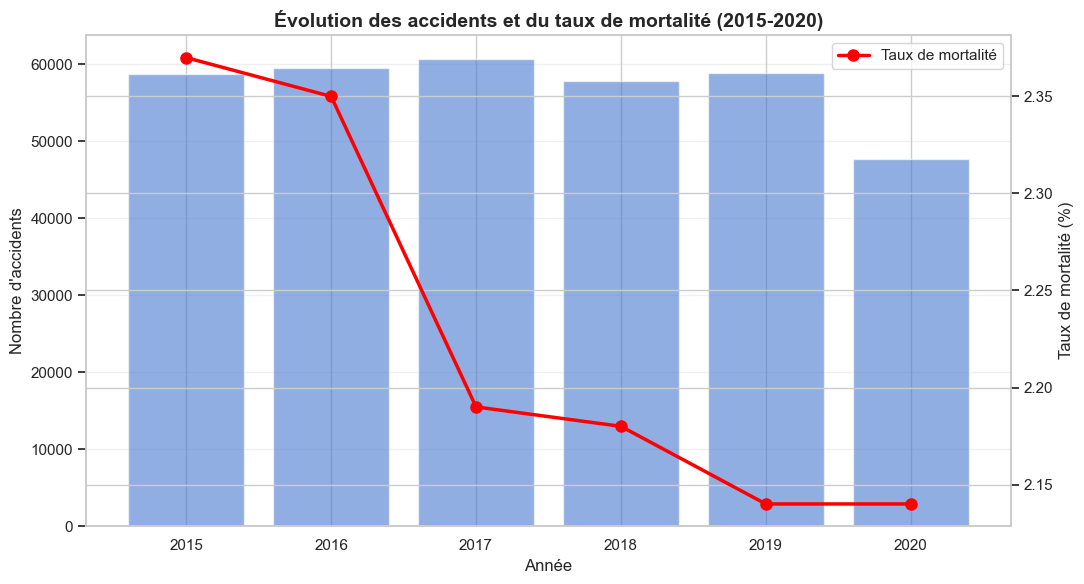

In [10]:
plot_accidents_mortalite(stats_annuelles)

### 5.3 Évolution du nombre de tués par année

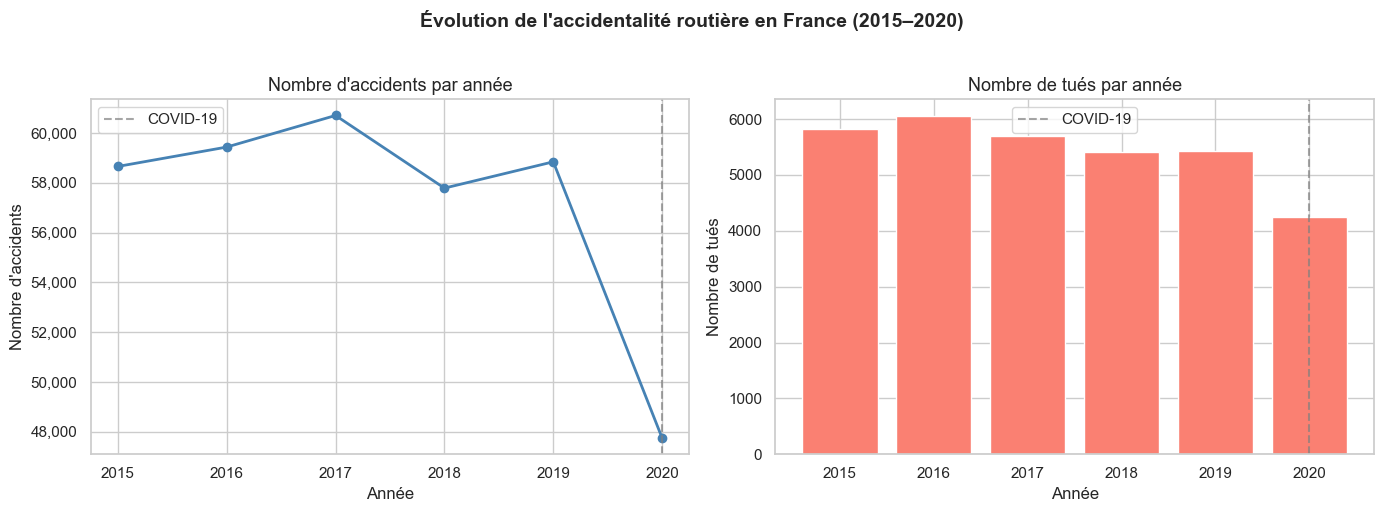

In [11]:
plot_accidents_et_tues(stats_annuelles)

**Interprétation :**
- **Graphique gauche (accidents)** : hausse légère 2015–2017, baisse à partir de 2018, chute marquée en 2020 liée à la crise sanitaire.
- **Graphique droit (tués)** : dynamique similaire avec une baisse moins prononcée qu'attendu, suggérant que la gravité moyenne des accidents ne diminue pas fortement.
- La ligne pointillée 2020 sert de repère visuel pour identifier cette rupture conjoncturelle.

### 5.4 Répartition de la gravité

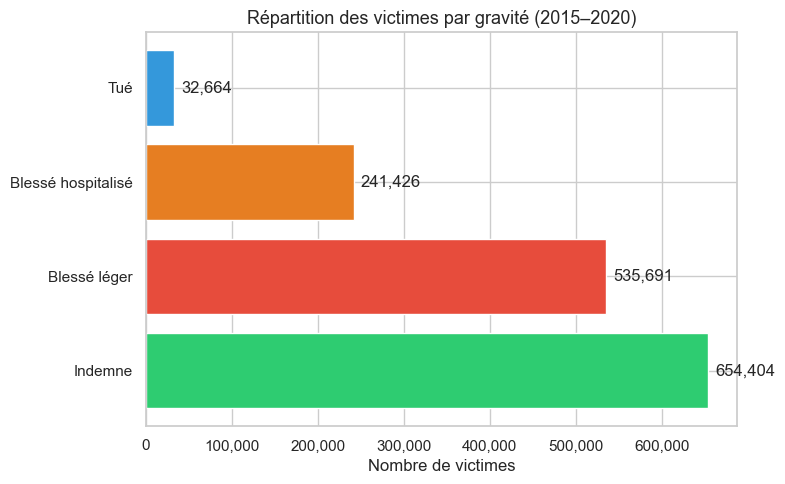


Pourcentages :
gravite_label
Indemne               44.69
Blessé léger          36.59
Blessé hospitalisé    16.49
Tué                    2.23


In [12]:
plot_repartition_gravite(df)

**Interprétation :** La répartition montre une **majorité de blessés légers** (36,59 %), ce qui traduit la prédominance d'accidents en milieu urbain à vitesse modérée. Les tués représentent une minorité (2,23 %) mais constituent l'enjeu central de la sécurité routière.

Ce fort déséquilibre de classes est un défi important pour la modélisation : c'est pourquoi on utilise `class_weight='balanced'` dans nos modèles.

### 5.5 Accidentalité par heure de la journée

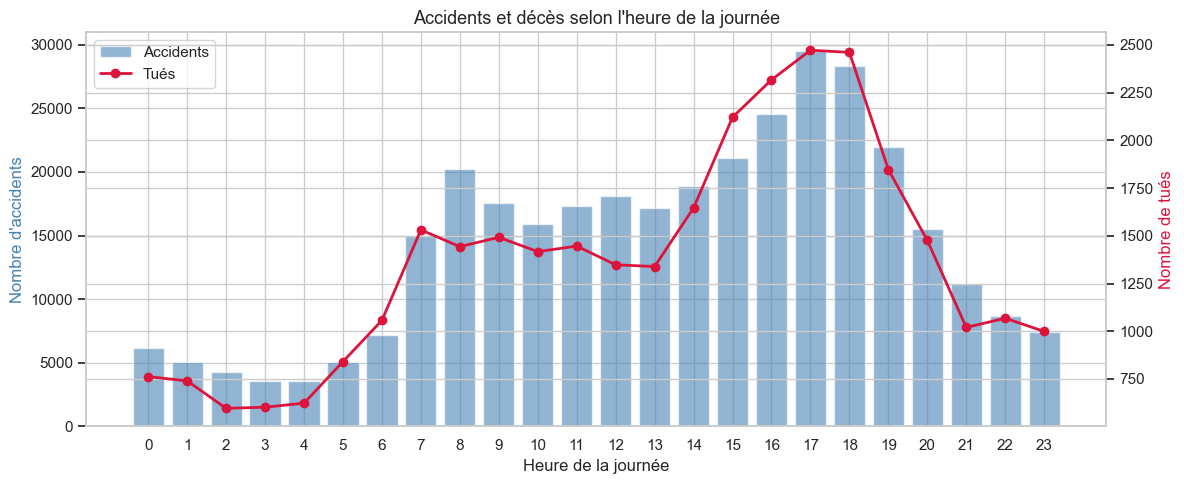

In [13]:
plot_accidents_par_heure(df)

**Interprétation :** Le graphique révèle deux dynamiques distinctes :
- **Volume d'accidents** (barres bleues) : deux pics aux heures de pointe — matin (8h-9h) et soir (17h-18h).
- **Nombre de tués** (courbe rouge) : paradoxalement, la nuit concentre proportionnellement plus de décès malgré un volume faible. Ce *paradoxe nocturne* s'explique par des vitesses plus élevées, une vigilance réduite (fatigue, alcool) et des routes moins fréquentées.

Il est important de bien regarder les échelles (les deux grandeurs sont différentes, choix fait dans un souci de lisibilité).

### 5.6 Gravité selon les conditions météo et la luminosité

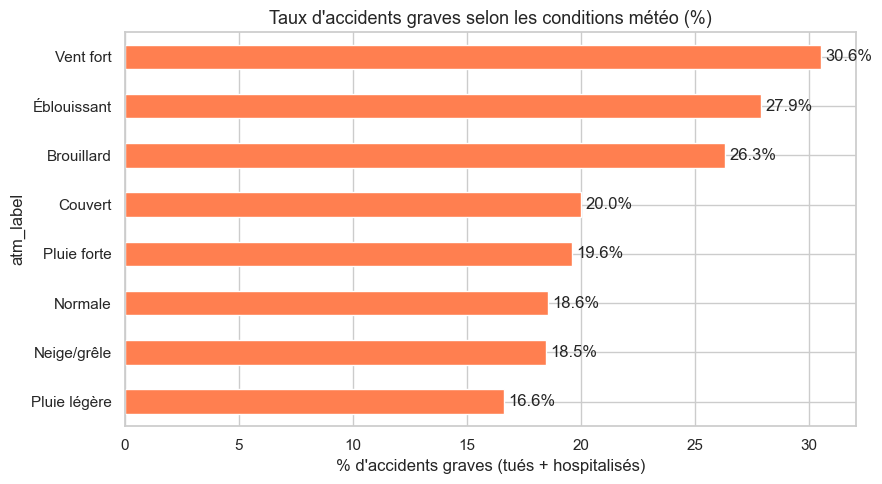

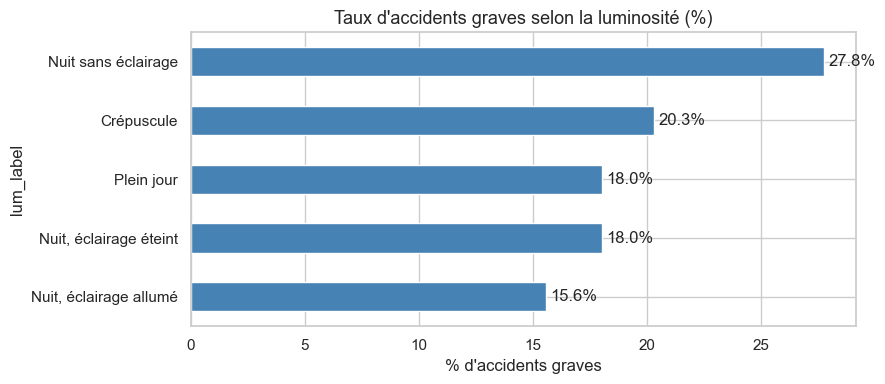

In [14]:
plot_gravite_meteo_luminosite(df)

**Interprétation :**

**Météo :** contre-intuitivement, les conditions de brouillard et de vent fort présentent des taux d'accidents graves plus élevés que la pluie. La pluie incite les conducteurs à réduire leur vitesse — effet protecteur qui compense le risque de dérapage.

**Luminosité :** la nuit sans éclairage public ressort comme la condition la plus meurtrière, justifiant les politiques d'éclairage des points noirs routiers.

### 5.7 Profil des victimes : âge et sexe

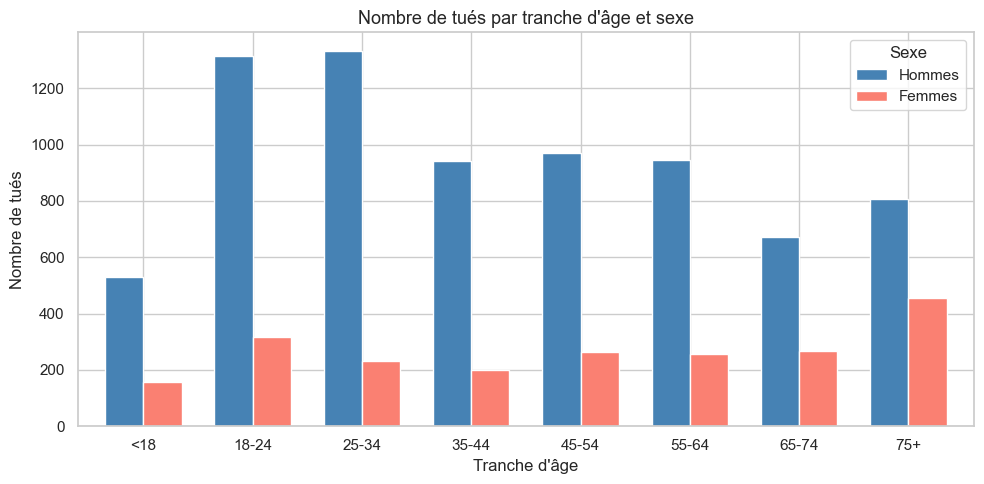

In [15]:
plot_tues_age_sexe(df)

**Interprétation :** On observe une **surreprésentation marquée des hommes parmi les personnes tuées** dans toutes les tranches d'âge (rapport d'environ 3 pour 1). Deux groupes se distinguent particulièrement : les **18–34 ans** (niveaux les plus élevés, surtout chez les hommes) et les **75 ans et plus**.

### 5.8 Cartographie des accidents graves

In [16]:
# La carte est sauvegardée en HTML dans le dossier courant.
# On observe des concentrations fortes en Île-de-France et dans les grandes métropoles,
# ainsi que les axes autoroutiers visibles comme 'couloirs' de points chauds.
carte = generer_carte_chaleur(df)
carte  # Affiche dans Jupyter

Carte sauvegardée : carte_accidents_graves.html


---
## 6. Modélisation : prédire la gravité d'un accident

**Objectif :** Prédire si un accident est grave (tué ou hospitalisé) ou non, à partir des caractéristiques de l'accident.

**Variable cible :** `grave` (1 = tué ou hospitalisé, 0 = indemne ou blessé léger)

### 6.1 Préparation des features

In [17]:
# Les 19 variables retenues couvrent les 4 dimensions explicatives :
# environnementales, infrastructurelles, comportementales, socio-démographiques.
# Les variables à plus de 60% de manquants (vma, secu2/3) sont exclues.
X, y, features_dispo = preparer_donnees_modelisation(df)

Features disponibles (19) : ['lum', 'agg', 'int', 'atm', 'col', 'catr', 'circ', 'nbv', 'surf', 'infra', 'situ', 'catv', 'manv', 'sexe', 'trajet', 'secu1', 'heure', 'week_end', 'annee']
Dataset pour modélisation : 1,464,185 lignes
Équilibre des classes :
grave
0    0.813
1    0.187
Name: proportion, dtype: float64


### 6.2 Split train / test

In [18]:
# On réserve 20% des données pour le test (bon comme ce qu'on faisait en Daveiga).
# stratify=y garantit que la proportion de cas graves/non graves est identique
# dans le train et le test → évite un biais d'évaluation.
X_train, X_test, y_train, y_test = splitter_donnees(X, y)

Train : 1,171,348 exemples
Test  : 292,837 exemples


### 6.3 Entraînement du modèle (Random Forest)

In [19]:
# Pipeline : SimpleImputer (most_frequent) → RandomForestClassifier
# class_weight='balanced' gère le déséquilibre des classes
pipeline_rf = entrainer_random_forest(X_train, y_train)

Entraînement du Random Forest...
Entraînement terminé.


### 6.4 Évaluation

=== Rapport de classification ===
              precision    recall  f1-score   support

   Non grave       0.90      0.70      0.79    238019
       Grave       0.34      0.67      0.45     54818

    accuracy                           0.70    292837
   macro avg       0.62      0.69      0.62    292837
weighted avg       0.80      0.70      0.73    292837

AUC-ROC : 0.7574


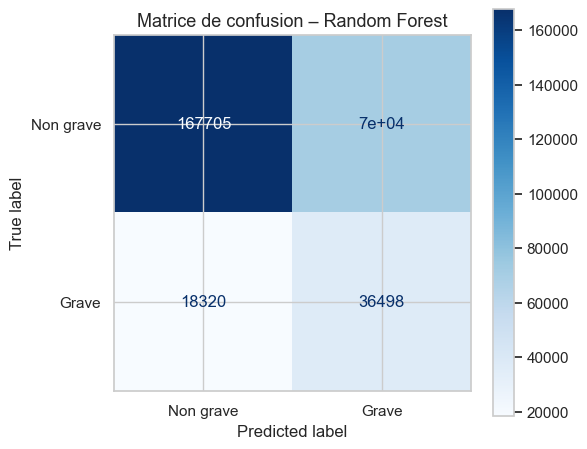

In [20]:
resultats_rf = evaluer_modele(pipeline_rf, X_test, y_test)

**Interprétation des résultats (selon l'IA) :**  
Le modèle présente une capacité correcte à discriminer les observations (AUC ≈ 0.77), mais souffre d'un déséquilibre dans ses performances selon les classes. La détection des cas graves est caractérisée par un rappel satisfaisant (≈ 0.69) mais une précision faible (≈ 0.33), traduisant un grand nombre de faux positifs. Ce comportement s'explique par le déséquilibre des classes.

**Piste d'amélioration :** ajuster le seuil de classification → `y_pred = (y_proba > 0.3).astype(int)`

### 6.5 Importance des variables

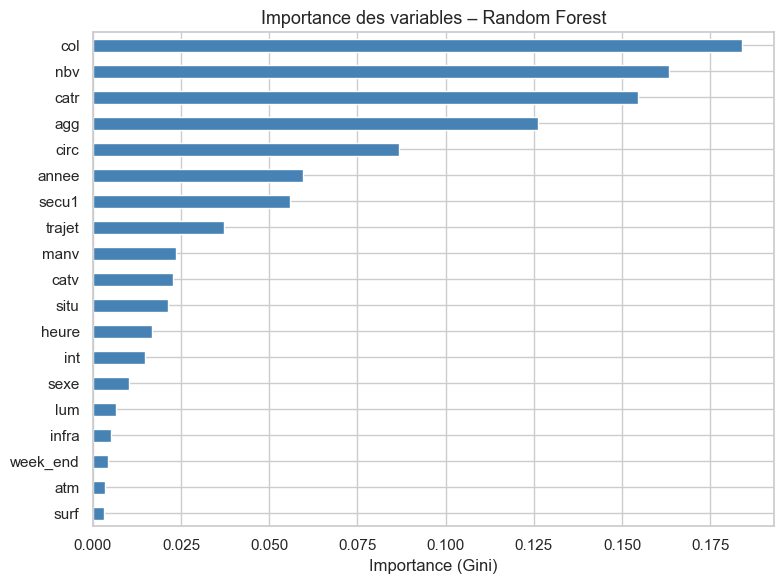


Top 5 variables les plus importantes :
col     0.183837
nbv     0.163365
catr    0.154617
agg     0.126074
circ    0.086860


In [21]:
# Variables attendues en tête : catv, catr, heure, lum, atm
# → cohérent avec l'analyse descriptive, renforce la validité du modèle
plot_importance_variables(pipeline_rf, features_dispo)

### 6.6 Comparaison de modèles

In [22]:
# Comparaison : Régression logistique vs Random Forest vs Gradient Boosting
# Le Random Forest est retenu comme modèle principal (meilleur compromis
# performance / interprétabilité / temps d'entraînement).
# Si l'AUC du Gradient Boosting est supérieure → préférable en production
# mais au détriment de l'interprétabilité.
df_comparaison = comparer_modeles(X_train, X_test, y_train, y_test)
df_comparaison

→ Régression logistique... OK
→ Random Forest... OK
→ Gradient Boosting... OK

=== Comparaison des modèles ===
               Modèle  AUC-ROC  F1 (grave)
    Gradient Boosting   0.7644      0.2520
        Random Forest   0.7574      0.4516
Régression logistique   0.6549      0.3742


,Modèle,AUC-ROC,F1 (grave)
2,Gradient Boosting,0.7644,0.2520
1,Random Forest,0.7574,0.4516
0,Régression logistique,0.6549,0.3742
